# **Project 44: Big Mart Sales Predictor**

***pandas*** : *Imports the pandas library, which is used for data manipulation and analysis. It is commonly abbreviated as pd.*

***numpy*** : *Imports the numpy library, which provides support for large, multi-dimensional arrays and matrices, along with a collection of mathematical functions to operate on these arrays. It is commonly abbreviated as np.*

***matplotlib*** : *Imports the pyplot module from matplotlib, a plotting library for creating static, animated, and interactive visualizations in Python. It is commonly abbreviated as plt.*

***seaborn*** : *Imports the seaborn library, which provides a high-level interface for drawing attractive and informative statistical graphics. It is commonly abbreviated as sns.*

***warnings*** : *Imports the warnings module, which is used to handle warnings in Python code, this module helps manage and filter warning messages.*

***redshift_connector*** : *Imports the redshift_connector library, which is used to connect and interact with Amazon Redshift databases.*

# **Data Loading**

**The line !pip install redshift_connector is a command used to install the redshift_connector library via pip, which is the package installer for Python.**

In [1]:
!pip install redshift_connector

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: lxml
    Found existing installation: lxml 6.0.2
    Uninstalling lxml-6.0.2:
      Successfully uninstalled lxml-6.0.2


**Importing these libraries for Data Loading, Data Cleaning and Data Visualization.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import redshift_connector

**warnings.simplefilter("ignore"): Suppresses warning messages in the output.**


In [3]:
warnings.simplefilter("ignore")

**To establish a connection to an Amazon Redshift database using the redshift_connector library, the redshift_connector.connect method is used. It requires specifying connection details such as the host URL, database name, user credentials, and port number to connect to the Redshift cluster. This setup allows Python to interact with the Redshift database for querying and data manipulation.**

In [ ]:
conn = redshift_connector.connect(
    host="bigmartsalecluster.ccaqar8aasih.eu-north-1.redshift.amazonaws.com",
    database="dev",
    user="admin",
    password="Your Password Here!",
    port = 5439
)

**query = "SELECT * FROM public.data;": Defines an SQL query to select all rows from the data table in the public schema of the database.**

**df = pd.read_sql(query, conn): Executes the SQL query using the established connection conn and reads the results into a pandas DataFrame df, allowing for easy data manipulation and analysis.**

In [ ]:
query = "SELECT * FROM public.data;"
df = pd.read_sql(query, conn)

**df = pd.read_csv("/content/Train-Big-Mart-Sales.csv"): Reads a CSV file named BigMart.csv from the specified path and loads its content into a pandas DataFrame df.**

**pd.set_option("display.max_columns", None): Configures pandas to display all columns of the DataFrame when printing or displaying it.**

**pd.set_option("display.max_rows", None): Configures pandas to display all rows of the DataFrame when printing or displaying it.**

**df.head(5): Displays the first 5 rows of the DataFrame df, providing a quick view of the data.**

In [26]:
df = pd.read_csv("/content/Train-Big-Mart-Sales.csv")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


**The df.info() method provides a concise summary of the DataFrame df.**

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


**df[df['Item_Weight'].notna()]: Uses this boolean Series to filter the DataFrame, retaining only rows where Item_Weight is not null.**

In [28]:
df=df[df['Item_Weight'].notna()]

**The line df.isnull().sum() calculates and displays the number of missing (null) values for each column in the DataFrame df.**

In [29]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


**The code fills missing values in the "Outlet_Size" column of the dataframe with the string "No Information."**

In [30]:
df["Outlet_Size"] = df["Outlet_Size"].fillna("No Information")

**The line df["Item_Fat_Content"].value_counts() counts and displays the number of occurrences of each unique value in the Item_Fat_Content column of the DataFrame df.**

In [31]:
df["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
Low Fat,4222
Regular,2388
LF,260
reg,106
low fat,84


**The code replaces specific values in the Item_Fat_Content column with standardized labels ("Low Fat" and "Regular"). It then counts and displays the number of occurrences of each unique value in the updated column.**

In [32]:
df.replace({"Item_Fat_Content": {"low fat" : "Low Fat", "LF" : "Low Fat", "reg" : "Regular"}}, inplace=True)
df["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
Low Fat,4566
Regular,2494


# **Data Visualization**

**This code creates a bar plot to visualize the distribution of values in the Outlet_Size column of the DataFrame df. The plot uses the Set1 color palette and displays the count of each unique value in Outlet_Size.**

**This graph displays the distribution and count of each outlet size.**

<Axes: xlabel='Outlet_Size', ylabel='count'>

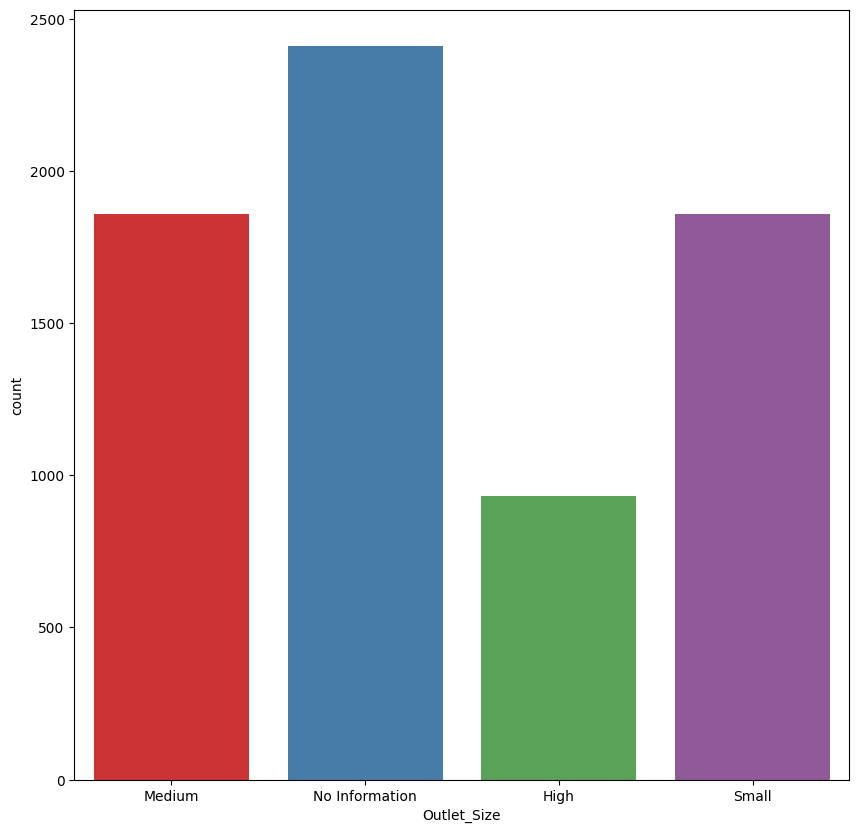

In [33]:
plt.figure(figsize=(10, 10))
sns.countplot(x = "Outlet_Size", data=df, palette="Set1")

**The code df["Outlet_Size"].value_counts() counts and displays the number of occurrences of each unique value in the Outlet_Size column of the DataFrame df. This provides insight into the distribution of outlet sizes in the dataset.**

In [34]:
df["Outlet_Size"].value_counts()

,count
Outlet_Size,
No Information,2410
Small,1860
Medium,1858
High,932


**This code generates a bar plot showing the distribution of values in the Outlet_Type column of the DataFrame df. It uses the Set1 color palette and visualizes the count of each unique Outlet_Type.**

**This graph shows the distribution and count of each outlet type.**

<Axes: xlabel='Outlet_Type', ylabel='count'>

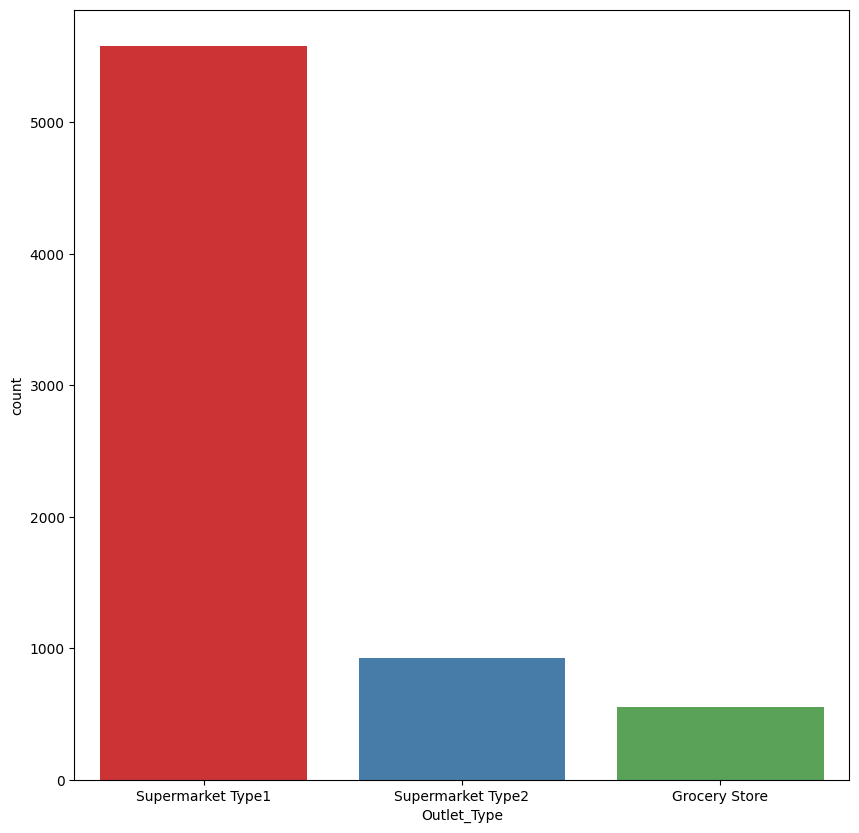

In [35]:
plt.figure(figsize=(10,10))
sns.countplot(x='Outlet_Type',data=df, palette="Set1")

**This code creates a bar plot to visualize the distribution of values in the Outlet_Establishment_Year column of the DataFrame df. The plot uses the Set1 color palette and shows the count of outlets established in each year.**

**This graph illustrates the distribution and count of outlets by establishment year.**

<Axes: xlabel='Outlet_Establishment_Year', ylabel='count'>

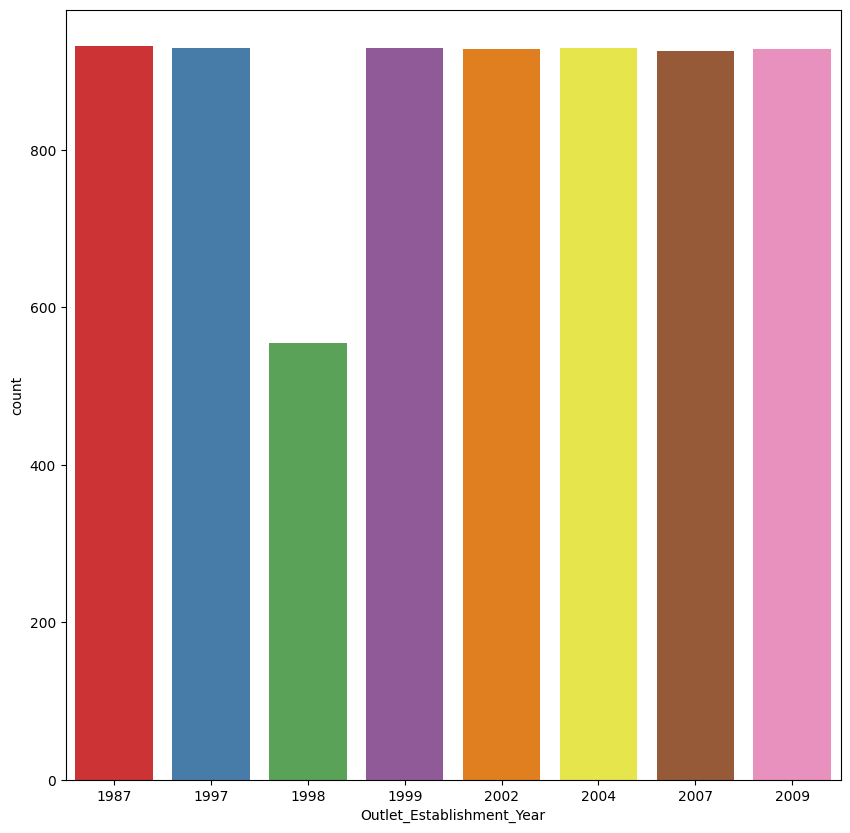

In [36]:
plt.figure(figsize=(10,10))
sns.countplot(x='Outlet_Establishment_Year',data=df, palette="Set1")

**This code creates a histogram to visualize the distribution of the logarithm of the Item_Weight column in the DataFrame df. The histogram is colored red and helps in understanding the distribution of the transformed weight data.**

**This graph presents a histogram of item weights, revealing that most items have a weight around 3.0, with the count of items at this weight exceeding 500.**

<Axes: xlabel='Item_Weight', ylabel='Count'>

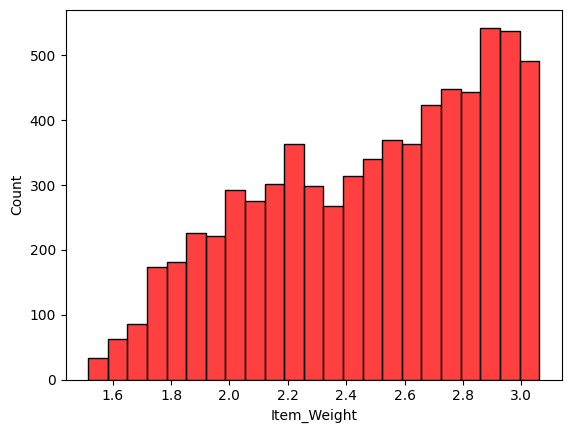

In [37]:
sns.histplot(np.log(df['Item_Weight']),color='red')

**This code generates a histogram to display the distribution of the Item_Visibility column in the DataFrame df. The histogram is colored red, showing how values are spread across different visibility levels.**

**This graph analyzes item visibility, showing that most items have a visibility of 0.00, with the count of such items approaching 600.**

<Axes: xlabel='Item_Visibility', ylabel='Count'>

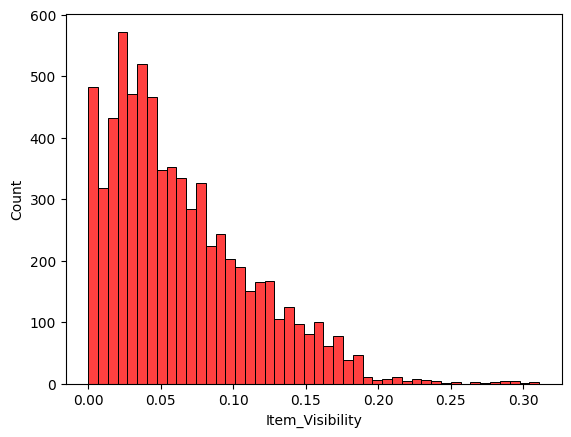

In [38]:
sns.histplot(df['Item_Visibility'],color='red')

**The code df.head(5) displays the first 5 rows of the DataFrame df, providing a quick overview of the dataset's initial records and their contents.**

In [39]:
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,No Information,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


# **Data Cleaning**

**Label Encoding: Uses LabelEncoder to convert categorical columns (Item_Fat_Content, Outlet_Identifier, Outlet_Size, Outlet_Location_Type, Outlet_Type) into numerical values.**

**Column Dropping: Removes the Item_Identifier column from the DataFrame df.**

**One-Hot Encoding: Applies one-hot encoding to convert categorical variables into binary (dummy) variables, creating a new DataFrame with these binary columns.**

**Display DataFrame: Shows the first few rows of the transformed DataFrame df.**

In [40]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

col_encode = ['Item_Fat_Content','Outlet_Identifier','Outlet_Size','Outlet_Location_Type','Outlet_Type']

for i in col_encode:
  df[i]=LE.fit_transform(df[i])

df = df.drop(columns=['Item_Identifier'])
df = pd.get_dummies(df)

df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,9.30,0,0.016047,249.8092,7,1999,1,0,1,3735.1380,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
1,5.92,1,0.019278,48.2692,3,2009,1,2,2,443.4228,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,17.50,0,0.016760,141.6180,7,1999,1,0,1,2097.2700,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,19.20,1,0.000000,182.0950,0,1998,2,2,0,732.3800,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,8.93,0,0.000000,53.8614,1,1987,0,2,1,994.7052,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


**The code df.columns lists the names of all columns in the DataFrame df, allowing you to see the structure and available features after any transformations or encodings have been applied.**

In [41]:
df.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_MRP',
       'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales',
       'Item_Type_Baking Goods', 'Item_Type_Breads', 'Item_Type_Breakfast',
       'Item_Type_Canned', 'Item_Type_Dairy', 'Item_Type_Frozen Foods',
       'Item_Type_Fruits and Vegetables', 'Item_Type_Hard Drinks',
       'Item_Type_Health and Hygiene', 'Item_Type_Household', 'Item_Type_Meat',
       'Item_Type_Others', 'Item_Type_Seafood', 'Item_Type_Snack Foods',
       'Item_Type_Soft Drinks', 'Item_Type_Starchy Foods'],
      dtype='object')

**Column Selection: Specifies a list of column names related to Item_Type in the DataFrame df.**

**Type Conversion: Converts the data type of these specified columns to integers (int).**

**Display DataFrame: Shows the first 5 rows of the DataFrame df after the type conversion.**

In [42]:
columns = ['Item_Type_Baking Goods', 'Item_Type_Breads', 'Item_Type_Breakfast',
       'Item_Type_Canned', 'Item_Type_Dairy', 'Item_Type_Frozen Foods',
       'Item_Type_Fruits and Vegetables', 'Item_Type_Hard Drinks',
       'Item_Type_Health and Hygiene', 'Item_Type_Household', 'Item_Type_Meat',
       'Item_Type_Others', 'Item_Type_Seafood', 'Item_Type_Snack Foods',
       'Item_Type_Soft Drinks', 'Item_Type_Starchy Foods']

df[columns] = df[columns].astype(int)

df.head(5)

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,9.30,0,0.016047,249.8092,7,1999,1,0,1,3735.1380,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,5.92,1,0.019278,48.2692,3,2009,1,2,2,443.4228,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,17.50,0,0.016760,141.6180,7,1999,1,0,1,2097.2700,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,19.20,1,0.000000,182.0950,0,1998,2,2,0,732.3800,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,8.93,0,0.000000,53.8614,1,1987,0,2,1,994.7052,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


**Figure Size: Sets the size of the plot to 20x20 inches.**

**Heatmap: Uses sns.heatmap to display the correlation matrix with annotations (annot=True) to show correlation values, using the coolwarm color palette.**

**Line Widths: Adds lines between cells with a width of 1.0 for better readability.**

<Axes: >

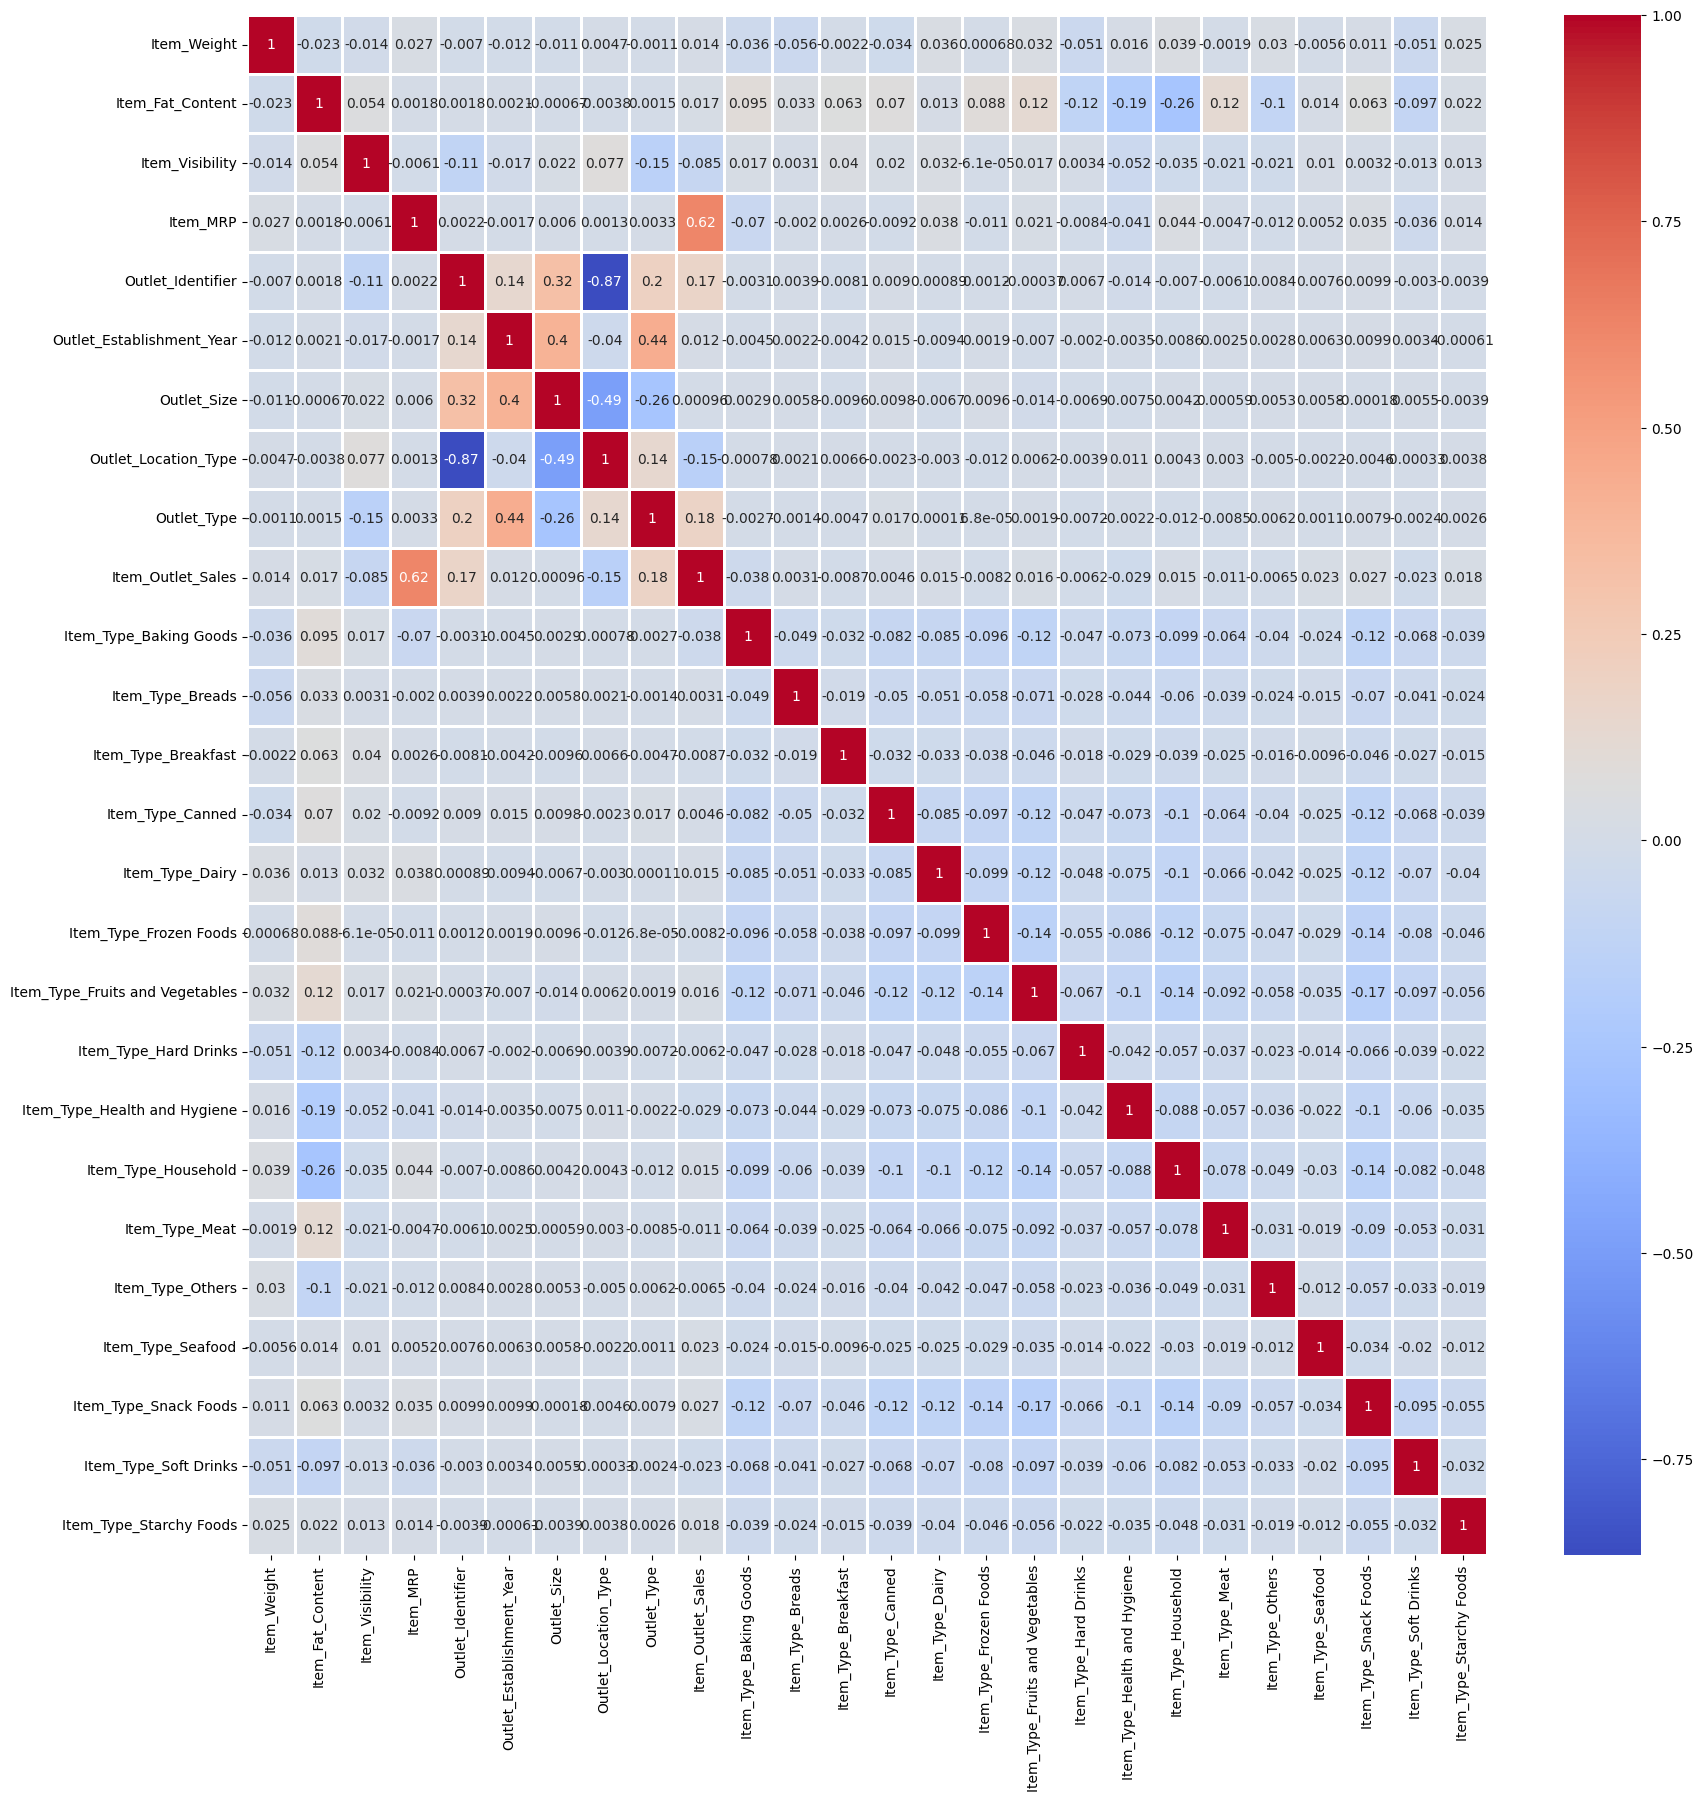

In [43]:
plt.figure(figsize=(20, 20))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=1.0)

**The code df.columns lists the names of all columns in the DataFrame df, allowing you to see the structure and features of the dataset.**

In [44]:
df.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_MRP',
       'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales',
       'Item_Type_Baking Goods', 'Item_Type_Breads', 'Item_Type_Breakfast',
       'Item_Type_Canned', 'Item_Type_Dairy', 'Item_Type_Frozen Foods',
       'Item_Type_Fruits and Vegetables', 'Item_Type_Hard Drinks',
       'Item_Type_Health and Hygiene', 'Item_Type_Household', 'Item_Type_Meat',
       'Item_Type_Others', 'Item_Type_Seafood', 'Item_Type_Snack Foods',
       'Item_Type_Soft Drinks', 'Item_Type_Starchy Foods'],
      dtype='object')

# **Model Building**

**Feature Set (X): Defines X as a DataFrame containing a subset of columns from df that will be used as features for model training. These columns include various property attributes and characteristics.**

**Target Variable (y): Defines y as a DataFrame containing the logerror column, which will be used as the target variable for model training.**

In [45]:
X = df[['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_MRP',
       'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type',
       'Item_Type_Baking Goods', 'Item_Type_Breads', 'Item_Type_Breakfast',
       'Item_Type_Canned', 'Item_Type_Dairy', 'Item_Type_Frozen Foods',
       'Item_Type_Fruits and Vegetables', 'Item_Type_Hard Drinks',
       'Item_Type_Health and Hygiene', 'Item_Type_Household', 'Item_Type_Meat',
       'Item_Type_Others', 'Item_Type_Seafood', 'Item_Type_Snack Foods',
       'Item_Type_Soft Drinks', 'Item_Type_Starchy Foods']]

y = df[['Item_Outlet_Sales']]

**Initialize Scalers: Create MinMaxScaler instances for both features (X) and target (y), setting transform="pandas" to ensure output as pandas DataFrames.**

**Fit and Transform Features: Scale the feature set X to the range [0, 1] using Scaler_X.**

**Fit and Transform Target: Scale the target variable y to the range [0, 1] using Scaler_y.**

In [46]:
from sklearn.preprocessing import MinMaxScaler

Scaler_X = MinMaxScaler().set_output(transform = "pandas")

X = Scaler_X.fit_transform(X)

Scaler_y = MinMaxScaler().set_output(transform = "pandas")

y = Scaler_y.fit_transform(y)

**train_test_split: From sklearn.model_selection, this function splits the dataset into training and testing sets, allowing you to evaluate the performance of your model on unseen data.**

**mean_squared_error: From sklearn.metrics, this function calculates the mean squared error (MSE) between predicted and actual values, providing a measure of the prediction error.**

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

**train_test_split: Splits the feature set X and the target variable y into training and testing subsets.**

**train_size=0.80: Specifies that 80% of the data should be used for training (X_train and y_train), and the remaining 20% for testing (X_test and y_test).**

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**This code retrieves the dimensions of the training and testing sets:**

**X_train.shape: Dimensions of the training feature set.**

**X_test.shape: Dimensions of the testing feature set.**

**y_train.shape: Dimensions of the training target variable.**

**y_test.shape: Dimensions of the testing target variable.**

**These outputs show the number of samples and features (or target values) in each subset.**

In [49]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5648, 25), (1412, 25), (5648, 1), (1412, 1))

**1: Initialize Model: Create a LinearRegression model with intercept fitting enabled and parallel processing.**

**2: Train Model: Fit the model using X_train and y_train.**

**3: Predict: Generate predictions with the model on X_test.**

**4: Evaluate: Calculate and print the mean squared error between predictions and actual values using mean_squared_error.**

In [50]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression(fit_intercept = True, n_jobs = -1)

LR.fit(X_train, y_train)

y_pred = LR.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Linear Regression: ", MSE)

Mean Squared Error For Linear Regression:  0.011670713695923781


**1: Initialize Model: Create a RandomForestRegressor with specified parameters for minimum samples per leaf and split.**

**2: Train Model: Fit the RandomForest model using X_train and y_train.**

**3: Predict: Generate predictions with the RandomForest model on X_test (Note: there’s an error here; y_pred should be calculated using RFR.predict(X_test)).**

**4: Evaluate: Calculate and print the mean squared error between the predictions and the actual values using mean_squared_error.**

In [51]:
from sklearn.ensemble import RandomForestRegressor

RFR = RandomForestRegressor(min_samples_leaf=10, min_samples_split=20)

RFR.fit(X_train, y_train)

y_pred = LR.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Random Forest Regressor: ", MSE)

Mean Squared Error For Random Forest Regressor:  0.011670713695923781


**1: Initialize Model: Create a DecisionTreeRegressor with specified parameters for complexity pruning and maximum depth.**

**2: Train Model: Fit the Decision Tree model using X_train and y_train.**

**3: Predict: Generate predictions with the Decision Tree model on X_test.**

**4: Evaluate: Calculate and print the mean squared error between the predictions and the actual values using mean_squared_error.**

In [52]:
from sklearn.tree import DecisionTreeRegressor

DTR = DecisionTreeRegressor(ccp_alpha= 1.0, max_depth = 300)

DTR.fit(X_train, y_train)

y_pred = DTR.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Decision Tree Regressor: ", MSE)

Mean Squared Error For Decision Tree Regressor:  0.02326296329722518


**1: Initialize Model: Create an SVR (Support Vector Regressor) with specified parameters for regularization and maximum iterations.**

**2: Train Model: Fit the SVR model using X_train and y_train.**

**3: Predict: Generate predictions with the SVR model on X_test.**

**4: Evaluate: Calculate and print the mean squared error between the predictions and the actual values using mean_squared_error.**

In [53]:
from sklearn.svm import SVR

svr = SVR(C=1.0 , max_iter=500)

svr.fit(X_train, y_train)

y_pred = svr.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Support Vector Regressor: ", MSE)

Mean Squared Error For Support Vector Regressor:  0.014502576492933067


**1: Initialize Model: Create a Ridge regression model with specified tolerance and alpha parameters.**

**2: Train Model: Fit the Ridge model using X_train and y_train.**

**3: Predict: Generate predictions with the Ridge model on X_test.**

**4: Evaluate: Calculate and print the mean squared error between the predictions and the actual values using mean_squared_error.**

In [54]:
from sklearn.linear_model import Ridge

Rg = Ridge(tol=20, alpha=1.0)

Rg.fit(X_train, y_train)

y_pred = Rg.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Ridge: ", MSE)

Mean Squared Error For Ridge:  0.011678725183911408


**1: Initialize Model: Create a Lasso regression model with specified parameters for intercept fitting, regularization strength (alpha), and maximum iterations.**

**2: Train Model: Fit the Lasso model using X_train and y_train.**

**3: Predict: Generate predictions with the Lasso model on X_test.**

**4: Evaluate: Calculate and print the mean squared error between the predictions and the actual values using mean_squared_error.**

In [55]:
from sklearn.linear_model import Lasso

Ls = Lasso(fit_intercept=True, alpha=1.0, max_iter=1000)

Ls.fit(X_train, y_train)

y_pred = Ls.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)

print("Mean Squared Error For Lasso: ", MSE)

Mean Squared Error For Lasso:  0.02326296329722517


# **Deep Learning**

**Import Layers: Import the Dense layer from tensorflow.keras.layers to define fully connected layers in a neural network.**

**Import Model: Import the Sequential model from tensorflow.keras.models to create a linear stack of layers for building neural network models.**

In [63]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

**Initialize Model: Create a Sequential model, which allows for stacking layers in a linear fashion.**

**Add Layers:**

- **Input Layer: Dense(1024, activation="relu", input_dim=49) initializes a fully connected layer with 1024 units and ReLU activation, accepting an input with 49 features.**

- **Hidden Layers: Dense(512, activation="relu") and Dense(256, activation="relu") add fully connected layers with 512 and 256 units respectively, both using ReLU activation.**

- **Output Layer: Dense(1, activation='linear') adds the final layer with 1 unit and a linear activation function, suitable for regression tasks.**

In [64]:
model = Sequential()

model.add(Dense(1024, activation="relu", input_dim = 25))
model.add(Dense(512, activation="relu"))
model.add(Dense(256, activation="relu"))
model.add(Dense(1, activation='linear'))

**The model.summary() method provides a detailed overview of the neural network model, including:**

**Layer Information: Displays each layer's type, output shape, and number of parameters.**

**Parameter Counts: Shows the total number of trainable and non-trainable parameters in the model.**

**Model Architecture: Summarizes the structure of the model, including the input shape and connections between layers.**

In [65]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1024)           │        26,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,009 (2.61 MB)

 Trainable params: 683,009 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

**Optimizer: 'adam' is used to optimize the model, which adapts the learning rate and helps in efficient training.**

**Loss Function: 'mean_squared_error' is specified for regression tasks to measure the average squared difference between predicted and actual values.**

**Metrics: ['accuracy'] is included to track the model's performance during training and evaluation, although accuracy is more commonly used for classification tasks. For regression, you might consider using metrics like mean_absolute_error or mean_squared_error for more relevant performance tracking.**

In [66]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

**Train the Model: model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.20) trains the neural network on the training data.**

**Epochs: epochs=50 specifies the number of complete passes through the training data.**

**Batch Size: batch_size=128 sets the number of samples per gradient update.**

**Validation Split: validation_split=0.20 reserves 20% of the training data for validation to monitor the model's performance on unseen data during training.**

In [67]:
history = model.fit(X_train, y_train, epochs=50, batch_size=128)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 4.9100e-04 - loss: 0.0305
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 2.8968e-04 - loss: 0.0112
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 3.0668e-04 - loss: 0.0111
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 8.1672e-04 - loss: 0.0105
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 5.4433e-04 - loss: 0.0111
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 5.7270e-04 - loss: 0.0112
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 9.7830e-05 - loss: 0.0103
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 3.7105e-04 - loss: 0.0108
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 2.9968e-04 - loss: 0.0103
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 2.5403e-04 - loss: 0.0113
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 4.1607e-04 - loss: 0.0100
Epoch 12/50
45/45 ━

# **Conclusion**

**After evaluating various regression models, the following results were observed:**

- **Linear Regression: Mean Squared Error (MSE) = 0.011**
- **Random Forest Regressor: Mean Squared Error (MSE) = 0.011**
- **Decision Tree Regressor: Mean Squared Error (MSE) = 0.023**
- **Support Vector Regressor: Mean Squared Error (MSE) = 0.014**
- **Ridge Regression: Mean Squared Error (MSE) = 0.011**
- **Lasso Regression: Mean Squared Error (MSE) = 0.023**

## **Deep Learning Results:**

**Epoch 50/50: Accuracy = 2.5007, Loss = 0.0079**

**Although multiple models, including Random Forest Regressor (RFR), Linear Regression, and Ridge Regression, achieved the same mean squared error, the Random Forest Regressor was chosen as the final model. This choice was made due to its robustness and consistent performance, demonstrating stability across different scenarios. The deep learning model showed significantly higher loss and lower accuracy compared to the traditional models, reinforcing the decision to use RFR for further predictions.**

# **Saving The Model**

* **Serializes and saves the trained Random Forest model for reuse without retraining.**

* **Persists the feature scaler to ensure identical input preprocessing during inference.**

* **Stores the target scaler so predicted outputs can be correctly inverse-transformed.**

In [68]:
import pickle

with open("Finalized-Model.pickle", "wb") as file:
    pickle.dump(RFR, file)

with open("Scaler_X.pickle", "wb") as file:
    pickle.dump(Scaler_X, file)

with open("Scaler_y.pickle", "wb") as file:
    pickle.dump(Scaler_y, file)